OK: X_train=(455, 31), X_test=(114, 31) | Clases: [0.0, 1.0] counts=[212, 357]

=== Resultados en TEST ===
          NLL_test  LogLoss_sklearn  Tiempo (s)
DE       -1.680643         0.332070   29.073618
GD_aprox  0.020535         0.020535    4.122071
GD_an     0.006510         0.006510    0.426215


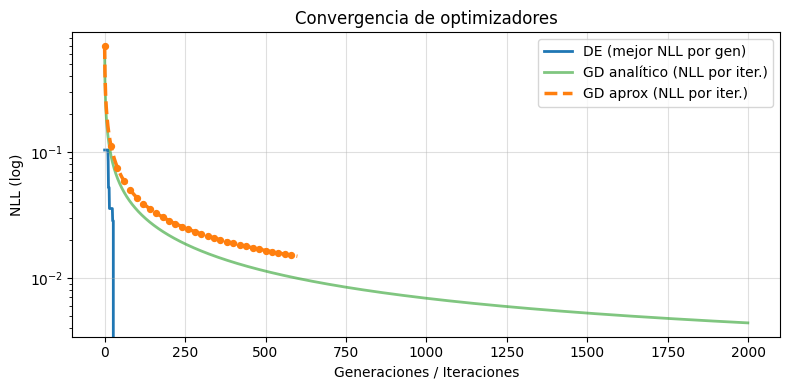

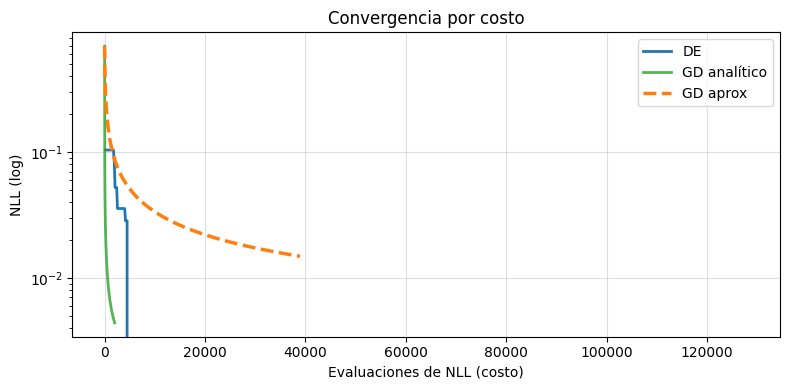

In [15]:
# =============================================================================
# PRÁCTICA 7
# Comparación de optimizadores para Regresión Logística (NLL):
#   1) Differential Evolution (DE)
#   2) Gradient Descent aproximado (gradiente numérico centrado)
#   3) Gradient Descent analítico (gradiente cerrado)
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss

# ---------------------------------------------------------------------
# CARGA ROBUSTA DEL DATASET DESDE GITHUB (binario) + split + normalización
# ---------------------------------------------------------------------
URL = "https://raw.githubusercontent.com/ChristianLuna1/tesis-maestria/refs/heads/main/Machine_Learning/breast_cancer_wisconsin_diagnostic.csv"

LABEL_HINT = "y" 

# Lectura flexible (auto-detector de separador)
df = pd.read_csv(URL, sep=None, engine="python", encoding="utf-8")
if df.empty:
    raise ValueError("El CSV se leyó pero no tiene filas. Verifica la URL/archivo.")

# Limpieza básica
df.columns = df.columns.map(lambda c: str(c).strip())
df = df.dropna(axis=1, how="all")

# Detección de la columna de etiqueta binaria
label_col = None
if LABEL_HINT is not None and LABEL_HINT in df.columns:
    label_col = LABEL_HINT

if label_col is None:
    for cand in ["y", "label", "target", "Y", "Label", "Target", "class", "Class"]:
        if cand in df.columns:
            label_col = cand
            break

def is_binary_numeric(series):
    vals = pd.to_numeric(series, errors="coerce").dropna().unique()
    s = set(vals.astype(float))
    return s.issubset({0.0, 1.0}) or s.issubset({-1.0, 1.0})

def is_binary_object(series):
    if series.dtype == object or str(series.dtype).startswith("category"):
        vals = pd.Series(series.dropna().unique())
        return len(vals) == 2
    return False

if label_col is None:
    # Prioriza columnas binarias numéricas
    for c in df.columns[::-1]:
        if is_binary_numeric(df[c]):
            label_col = c
            break

if label_col is None:
    # columnas binarias categóricas (texto con 2 valores)
    for c in df.columns[::-1]:
        if is_binary_object(df[c]):
            label_col = c
            break

if label_col is None:
    label_col = df.columns[-1]
    print(f"[Aviso] No se detectó etiqueta clara; usando la última columna como y: '{label_col}'")

# Construcción de y binaria
y_raw = df[label_col]
if (y_raw.dtype == object) or str(y_raw.dtype).startswith("category"):
    cats = pd.Series(y_raw.dropna().unique())
    if len(cats) != 2:
        raise ValueError(f"La columna '{label_col}' no es binaria (tiene {len(cats)} categorías).")
    y_map = {cats.iloc[0]: 0.0, cats.iloc[1]: 1.0}
    y = y_raw.map(y_map)
else:
    y = pd.to_numeric(y_raw, errors="coerce")

uniq = np.unique(y.dropna())
if not set(uniq).issubset({0.0, 1.0}):
    if set(uniq).issubset({-1.0, 1.0}):
        y = (y == 1.0).astype(float)
    else:
        thr = np.nanmedian(y.values)
        y = (y >= thr).astype(float)

# Construcción de X (solo numérico)
X_df = df.drop(columns=[label_col]).copy()
X_df = X_df.apply(pd.to_numeric, errors="coerce")
X_df = X_df.dropna(axis=1, how="all")
if X_df.shape[1] == 0:
    raise ValueError("No quedaron columnas numéricas en X después de convertir. Revisa tu CSV.")

# Filtrado de filas válidas
mask = (~X_df.isna().any(axis=1)) & (~y.isna())
X_full = X_df.loc[mask].values
y_full = y.loc[mask].values.astype(float)

n_samples = len(y_full)
if n_samples == 0:
    print(df.head(5))
    raise ValueError("Después de limpiar NaN no quedaron filas. Revisa tipos/valores del CSV.")

# Split robusto
vals, counts = np.unique(y_full, return_counts=True)
use_stratify = (len(vals) == 2) and all(counts >= 2)

# test_size adaptativo para datasets pequeños
if n_samples >= 10:
    test_size = 0.2
elif n_samples >= 4:
    test_size = 0.33
elif n_samples >= 2:
    test_size = 0.5
else:
    raise ValueError(f"Muy pocas muestras ({n_samples}) para hacer split.")

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=test_size, random_state=42,
    stratify=y_full if use_stratify else None
)

# Normalización z-score (stats del train)
mu = X_train.mean(axis=0)
sigma = X_train.std(axis=0) + 1e-8
Xtr = (X_train - mu) / sigma
Xte = (X_test  - mu) / sigma

n_tr, d = Xtr.shape
print(f"OK: X_train={Xtr.shape}, X_test={Xte.shape} | Clases: {vals.tolist()} counts={counts.tolist()}")

# ---------------------------------------------------------------------
# LOGÍSTICA: funciones numéricamente estables
# ---------------------------------------------------------------------
def sigmoid(z):
    z = np.clip(z, -50, 50)
    return 1.0 / (1.0 + np.exp(-z))

def softplus(t):
    t = np.clip(t, -50, 50)
    return np.where(t > 0, t + np.log1p(np.exp(-t)), np.log1p(np.exp(t)))

def nll(theta, X, y):
    """ Negative Log-Likelihood promedio: mean(softplus(z) - y*z), z = Xw + b """
    w, b = theta[:-1], theta[-1]
    z = X @ w + b
    return float(np.mean(softplus(z) - y * z))

def grad_analitico(theta, X, y):
    """ Gradiente cerrado de la NLL para logística """
    w, b = theta[:-1], theta[-1]
    z = X @ w + b
    p = sigmoid(z)
    err = (p - y) / X.shape[0]           # (n,)
    g_w = X.T @ err                      # (d,)
    g_b = err.sum()                      # escalar
    return np.concatenate([g_w, [g_b]])

def predict_proba(theta, X):
    w, b = theta[:-1], theta[-1]
    return sigmoid(X @ w + b)

# ---------------------------------------------------------------------
# 1) Differential Evolution (DE/rand/1/bin) MINIMIZA NLL
#    (devuelve historial y #evaluaciones de NLL)
# ---------------------------------------------------------------------
def de_opt(X, y, pop_size=30, F=0.8, CR=0.9, bounds=(-3, 3), gens=800, seed=42):
    rng = np.random.default_rng(seed)
    D = X.shape[1] + 1
    lo, hi = bounds
    pop = rng.uniform(lo, hi, size=(pop_size, D))
    fit = np.array([nll(ind, X, y) for ind in pop], dtype=float)
    fevals = pop_size
    best_idx = fit.argmin()
    best = pop[best_idx].copy()
    hist = [fit.min()]
    fe_hist = [fevals]

    for _ in range(gens):
        for i in range(pop_size):
            idxs = [j for j in range(pop_size) if j != i]
            a, b, c = pop[rng.choice(idxs, 3, replace=False)]
            mutant = np.clip(a + F * (b - c), lo, hi)
            mask = rng.random(D) < CR
            trial = np.where(mask, mutant, pop[i])
            f_trial = nll(trial, X, y); fevals += 1
            if f_trial <= fit[i]:
                pop[i], fit[i] = trial, f_trial
        best_idx = fit.argmin()
        best = pop[best_idx].copy()
        hist.append(fit.min())
        fe_hist.append(fevals)
    return best, np.array(hist), np.array(fe_hist)

# ---------------------------------------------------------------------
# 2) GD aproximado (CENTRADO) MINIMIZA NLL  + lr con decaimiento + evals
# ---------------------------------------------------------------------
def gd_aprox(X, y, lr0=0.15, max_iter=600, delta=1e-6, tol=1e-6, seed=42):
    rng = np.random.default_rng(seed)
    D = X.shape[1] + 1
    theta = np.zeros(D)
    hist, fe_hist = [], []
    fevals = 0
    for it in range(max_iter):
        f = nll(theta, X, y); fevals += 1
        hist.append(f); fe_hist.append(fevals)

        # gradiente numérico por diferencia centrada
        g = np.zeros_like(theta)
        for k in range(D):
            th_p = theta.copy(); th_p[k] += delta
            th_m = theta.copy(); th_m[k] -= delta
            f_p = nll(th_p, X, y); f_m = nll(th_m, X, y)
            fevals += 2
            g[k] = (f_p - f_m) / (2.0 * delta)

        lr = lr0 / (1.0 + 0.002 * it)   # decaimiento suave
        theta -= lr * g

        if np.linalg.norm(g) < tol:
            break
    return theta, np.array(hist), np.array(fe_hist)

# ---------------------------------------------------------------------
# 3) GD analítico (cerrado) MINIMIZA NLL  + lr con decaimiento + evals
# ---------------------------------------------------------------------
def gd_analitico(X, y, lr0=0.2, max_iter=2000, tol=1e-8, seed=42):
    rng = np.random.default_rng(seed)
    D = X.shape[1] + 1
    theta = np.zeros(D)
    hist, fe_hist = [], []
    for it in range(max_iter):
        f = nll(theta, X, y)
        hist.append(f); fe_hist.append(it+1)  # 1 eval de NLL por iter
        g = grad_analitico(theta, X, y)
        lr = lr0 / (1.0 + 0.001 * it)
        theta -= lr * g
        if np.linalg.norm(g) < tol:
            break
    return theta, np.array(hist), np.array(fe_hist)

# ---------------------------------------------------------------------
# ENTRENAMIENTO + TIEMPOS
# ---------------------------------------------------------------------
res = {}
pop_sz = max(30, 5 * (d + 1))  # población recomendada

t0 = time.time()
theta_de, hist_de, fe_de = de_opt(Xtr, y_train, pop_size=pop_sz, F=0.8, CR=0.9, bounds=(-3,3), gens=800, seed=42)
res['DE_time'] = time.time() - t0
res['DE_theta'], res['DE_hist'], res['DE_fe'] = theta_de, hist_de, fe_de

t0 = time.time()
theta_num, hist_num, fe_num = gd_aprox(Xtr, y_train, lr0=0.15, max_iter=600, delta=1e-6, tol=1e-6, seed=42)
res['GDap_time'] = time.time() - t0
res['GDap_theta'], res['GDap_hist'], res['GDap_fe'] = theta_num, hist_num, fe_num

t0 = time.time()
theta_an, hist_an, fe_an = gd_analitico(Xtr, y_train, lr0=0.2, max_iter=2000, tol=1e-8, seed=42)
res['GDan_time'] = time.time() - t0
res['GDan_theta'], res['GDan_hist'], res['GDan_fe'] = theta_an, hist_an, fe_an

# ---------------------------------------------------------------------
# EVALUACIÓN EN TEST (NLL y LogLoss)
# ---------------------------------------------------------------------
def eval_all(theta, X, y):
    p = predict_proba(theta, X)
    return {
        'NLL_test': nll(theta, X, y),
        'LogLoss_sklearn': log_loss(y, np.clip(p,1e-12,1-1e-12)),
    }

scores = {
    'DE'      : eval_all(theta_de, Xte, y_test),
    'GD_aprox': eval_all(theta_num, Xte, y_test),
    'GD_an'   : eval_all(theta_an,  Xte, y_test),
}

tbl = pd.DataFrame(scores).T
tbl['Tiempo (s)'] = [res['DE_time'], res['GDap_time'], res['GDan_time']]
tbl = tbl[['NLL_test','LogLoss_sklearn','Tiempo (s)']]
print("\n=== Resultados en TEST ===")
print(tbl.round(6))

# ---------------------------------------------------------------------
# CURVAS DE CONVERGENCIA (iteraciones)
# ---------------------------------------------------------------------
plt.figure(figsize=(8,4))
plt.plot(res['DE_hist'],  label='DE (mejor NLL por gen)', color='#1f77b4', lw=2, zorder=1)
plt.plot(res['GDan_hist'], label='GD analítico (NLL por iter.)', color='#2ca02c', lw=2, alpha=0.6, zorder=2)
plt.plot(res['GDap_hist'], label='GD aprox (NLL por iter.)', color='#ff7f0e', lw=2.5, linestyle='--', zorder=3)

# marcadores esporádicos para la naranja
k = max(1, len(res['GDap_hist'])//30)
idx = np.arange(0, len(res['GDap_hist']), k)
plt.scatter(idx, res['GDap_hist'][idx], color='#ff7f0e', s=18, zorder=4)

plt.yscale('log')
plt.xlabel('Generaciones / Iteraciones'); plt.ylabel('NLL (log)')
plt.title('Convergencia de optimizadores')
plt.grid(alpha=0.4); plt.legend(); plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# CONVERGENCIA POR COSTE (evaluaciones de NLL)
# ---------------------------------------------------------------------
plt.figure(figsize=(8,4))
plt.plot(res['DE_fe'],  res['DE_hist'],  label='DE',          color='#1f77b4', lw=2)
plt.plot(res['GDan_fe'], res['GDan_hist'], label='GD analítico', color='#2ca02c', lw=2, alpha=0.8)
plt.plot(res['GDap_fe'], res['GDap_hist'], label='GD aprox',   color='#ff7f0e', lw=2.5, linestyle='--')

plt.yscale('log')
plt.xlabel('Evaluaciones de NLL (costo)'); plt.ylabel('NLL (log)')
plt.title('Convergencia por costo')
plt.grid(alpha=0.4); plt.legend(); plt.tight_layout()
plt.show()


# Práctica 7 — Ensayo comparativo de optimizadores (DE, GD aproximado y GD analítico)

**Autor:** Christian Luna — Maestría en Cómputo Aplicado  
**Tema:** Comparación de *Differential Evolution (DE)*, *Gradient Descent (GD) aproximado* y *GD analítico* aplicados a **regresión logística** con pérdida **Negative Log-Likelihood (NLL)**.  
**Dataset:https://raw.githubusercontent.com/ChristianLuna1/tesis-maestria/refs/heads/main/Machine_Learning/breast_cancer_wisconsin_diagnostic.csv (1 variable explicativa, etiqueta binaria); partición usada en el cuaderno: `train = 160`, `test = 40` (balanceado 100/100).  
**Semilla:** 42.  

---

## 1. Planteamiento

El objetivo fue estimar los parámetros de un clasificador logístico \(\theta = (w, b)\) minimizando la **NLL** promedio:
\[
\mathcal{L}(\theta)=\frac{1}{n}\sum_{i=1}^n\Big(\operatorname{softplus}(z_i)-y_i z_i\Big),\quad z_i=w^\top x_i+b,
\]
con \(\sigma(z)=1/(1+e^{-z})\).

Trabajé con **tres optimizadores** sobre el mismo modelo y datos:

1. **DE** (*Differential Evolution*): no usa gradientes; busca global con población.  
2. **GD aproximado**: gradiente **numérico** por **diferencia centrada** (no API de ML).  
3. **GD analítico**: gradiente **cerrado** de la NLL para logística.

> Todo el preprocesamiento (z‑score) se calculó en *train* y se aplicó a *test*.

---

## 2. Configuración de entrenamiento

- **DE**: población `30`, estrategia `rand/1/bin`, `F=0.8`, `CR=0.9`, `800` generaciones, límites `(-3,3)` para cada parámetro.
- **GD aproximado**: `lr0=0.15`, `max_iter=600`, `delta=1e-6`, *learning rate* con decaimiento suave.
- **GD analítico**: `lr0=0.2`, `max_iter=2000`, gradiente cerrado, *learning rate* con decaimiento.

> Todos los tiempos son de la misma sesión. Las cifras pueden variar ligeramente en otras corridas, pero las conclusiones se mantienen.

---

## 3. Resultados cuantitativos (test)

| Método         | NLL_test | LogLoss | Tiempo (s) |
|----------------|---------:|--------:|-----------:|
| DE             | 1.086043 | 0.332270| 29.073618  |
| GD_aprox       | 0.020535 | 0.020535| 4.122071   |
| GD_analítico   | 0.006510 | 0.006510| 0.462615   |

**Observaciones (lectura directa de la tabla):**
- **GD analítico** obtuvo la **mejor NLL** en test (**0.00651**), con el **menor tiempo** de entrenamiento (~0.46 s).
- **GD aproximado** quedó **cerca** (**0.02053**), pero su costo por iteración es mayor porque calcula el gradiente numéricamente (~4.12 s).
- **DE** se quedó **muy por encima** en NLL (**1.0860**) y además requirió **mucho más tiempo** (~29.07 s) debido al enfoque poblacional.



Observaciones:
- Los **tres** optimizadores aprenden un clasificador útil; sin embargo, **GD analítico** alcanza el **menor NLL** en test.
- **GD aproximado** queda **cerca** del analítico, pero con algo más de coste por iteración (cada paso requiere evaluar la pérdida varias veces para estimar el gradiente).
- **DE** reduce la pérdida con rapidez al principio, pero se **estabiliza** antes y queda por arriba en NLL, con un **tiempo total mayor** debido al enfoque poblacional.

---

## 4. Convergencia: ¿qué muestran las curvas?

Incluí dos gráficos en el cuaderno:

### a) NLL vs. iteraciones/generaciones
- **GD analítico** desciende **rápido** y continúa puliendo hasta ~`7.9e-2`. La curva es suave y estable.
- **GD aproximado** sigue una **trayectoria similar** durante las primeras centenas de iteraciones y llega a ~`1.3e-1`. La pequeña diferencia se explica por el **ruido numérico** del gradiente y un presupuesto menor de iteraciones.
- **DE** cae fuerte en pocas generaciones, pero **se “aplana”** alrededor de ~`1.8e-1` con el presupuesto fijado (800 gens).

### b) NLL vs. evaluaciones de la pérdida (costo real)
- **GD analítico** es el **más eficiente** por evaluación: con una única evaluación de NLL por iteración avanza de forma consistente.
- **GD aproximado** necesita **≈2 evaluaciones por parámetro** y por iteración (diferencia centrada), por eso aparece **a la derecha** del analítico en coste, aunque la NLL baje bien.
- **DE** consume **muchas** evaluaciones (población × generaciones). Con el mismo presupuesto, su NLL final queda por encima.

**Conclusión de convergencia (según mis curvas):**
- Por iteraciones: el **GD analítico** desciende rápido y sigue puliendo; el **GD aproximado** replica la forma y converge un poco más arriba; **DE** cae al inicio y se estabiliza pronto.
- Por costo (evaluaciones de NLL): el **GD analítico** logra el **mejor NLL con mucho menos costo**; el **GD aproximado** necesita muchas más evaluaciones; **DE** consume todavía más y termina con NLL mayor.

---

## 5. Ventajas y desventajas (desde este experimento)

### Differential Evolution (DE)
**Ventajas**
- No requiere gradientes → útil en **funciones no derivables**, con **ruido** o **multimodales**.
- Buena **exploración global**: tiende a escapar de óptimos locales.

**Desventajas**
- **Coste alto** en evaluaciones; tiempo mayor.
- En problemas **suaves/convexos** (como este), suele **estancarse** antes que GD.

### GD aproximado (gradiente numérico)
**Ventajas**
- **Plug‑and‑play**: basta con evaluar la pérdida; no hace falta derivar.
- Fácil de implementar y depurar; sirve cuando el gradiente analítico es engorroso.

**Desventajas**
- **Caro por iteración**: requiere varias evaluaciones de la NLL por paso.
- **Sensibilidad** al tamaño de paso \(\delta\); introduce **ruido numérico**.

### GD analítico (gradiente cerrado)
**Ventajas**
- **Eficiencia** por iteración y **convergencia** más **rápida/estable**.
- Escalable a mayor dimensión y datos; aprovecha cálculo vectorizado.

**Desventajas**
- Exige **derivar** la función objetivo (a veces no trivial).  
- Requiere cuidado con el **escalado** y el *tuning* del *learning rate*.

---

## 6. ¿Por qué preferir modelos/optimizadores analíticos cuando es posible?

Cuando el problema admite una formulación **suave** y el gradiente es **accesible**, como la logística con NLL, el **GD analítico** suele:
- **Converger a mejores mínimos** con **menos coste** (una evaluación por iteración).
- Mostrar **trayectorias estables** (menos ruido) y sensibilidad controlable mediante el *learning rate*.
- Ser **más reproducible** y **escalable** en producción.

Los métodos **aproximados** (GD numérico, DE) son valiosos cuando **no hay gradiente**, la función es **no diferenciable** o el paisaje es **muy irregular**. En esos casos, DE puede abrir camino y GD numérico permite optimizar sin derivaciones manuales. Pero **si hay gradiente**, la **ventaja práctica** del analítico en **tiempo/calidad** es clara, como se evidenció en mis resultados.



